In [1]:
# load the correlation results
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/scratch/correlation_results/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)

print("Rows:", len(ds))
display(ds.head())             # in a notebook


Rows: 69951


,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval,ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef,...,simple_LR-g9-s1-d0-f_stat,simple_LR-g9-s1-d0-hqic,simple_LR-g9-s1-d0-llf,simple_LR-g9-s1-d0-rsq,simple_LR-g9-s1-d0-rsq_adj,simple_LR-g9-s1-d0-sigma2,source_file,time_window,unit_index,z_score
index,,,,,,,,,,,,,,,,,,,,,
0,0.152402,0.120495,1.556492,0.089148,0.368827,0.899832,-0.020901,0.833563,-0.210290,0.123322,...,2.768431,NaN,-779.059920,0.007695,0.004915,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,9,False
1,0.167072,0.079958,1.756028,-0.192590,0.042605,-2.034970,0.118241,0.214108,1.244609,0.123618,...,0.000597,NaN,-681.181162,0.000002,-0.002799,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,9,False
2,0.032352,0.800006,0.253533,-0.185525,0.147099,-1.453067,0.192337,0.132300,1.508614,-0.048639,...,5.735645,NaN,-644.272340,0.015812,0.013055,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2_-1_0,9,False
3,0.083825,0.427871,0.793764,-0.033850,0.748948,-0.320279,0.006011,0.954721,0.056821,0.079978,...,1.378883,NaN,-770.762613,0.003848,0.001057,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,14,False
4,0.110529,0.181864,1.337697,-0.210355,0.010194,-2.583169,0.095946,0.242588,1.170519,0.210518,...,0.391524,NaN,-681.769576,0.001096,-0.001703,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,14,False


In [2]:
import importlib
import correlation_utils   # or the module where the function lives

importlib.reload(correlation_utils)

from correlation_utils import get_column_names

get_column_names(ds)

['ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-pval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-

In [10]:

import importlib
import correlation_utils   # or the module where the function lives

importlib.reload(correlation_utils)

from correlation_utils import select_units_by_significance


selected_based_on_sumQ, _, result_dicts,output_dicts_based_on_sumQ = select_units_by_significance(
    ds,
    pval_col="simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval",
    coef_col="simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef",
    time_window="-1_0",
    alpha=0.01,
    brain_areas=["SI","MA"],
    coef_col_sign=("positive", "negative"),
    output_time_window=["0.3_2","-1_0","0.3_2","-1_0"],
    output_columns=["simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-coef","simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef","simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-pval","simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval"]
)



selected_based_on_reward, _, result_dicts,output_dicts_based_on_reward = select_units_by_significance(
    ds,
    pval_col="simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-pval",
    coef_col="simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-coef",
    time_window="0.3_2",
    alpha=0.01,
    brain_areas=["SI","MA"],
    coef_col_sign=("positive", "negative"),
    output_time_window=["0.3_2","-1_0","0.3_2","-1_0"],
    output_columns=["simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-coef","simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef","simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-pval","simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval"]
)


=== Summary ===
SumQ only:   103
Reward only: 249
Overlap:     232


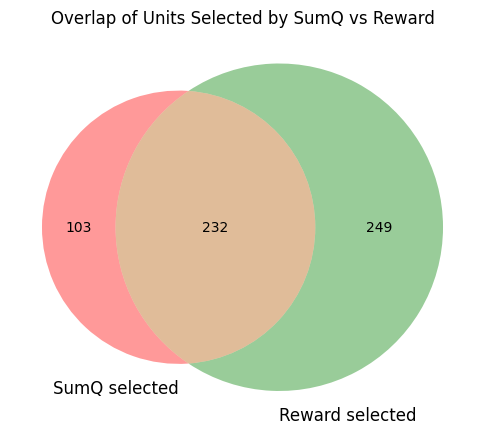

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ---------------------------------------------------------
# 1) Convert each selected list to a set of tuples
# ---------------------------------------------------------

set_sumQ = set(zip(
    selected_based_on_sumQ["session_id"],
    selected_based_on_sumQ["unit_index"]
))

set_reward = set(zip(
    selected_based_on_reward["session_id"],
    selected_based_on_reward["unit_index"]
))

# ---------------------------------------------------------
# 2) Compute overlap summary
# ---------------------------------------------------------

only_sumQ = len(set_sumQ - set_reward)
only_reward = len(set_reward - set_sumQ)
overlap = len(set_sumQ & set_reward)

print("\n=== Summary ===")
print(f"SumQ only:   {only_sumQ}")
print(f"Reward only: {only_reward}")
print(f"Overlap:     {overlap}")

# ---------------------------------------------------------
# 3) Plot Venn Diagram
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
venn2(
    subsets = (only_sumQ, only_reward, overlap),
    set_labels = ("SumQ selected", "Reward selected")
)
plt.title("Overlap of Units Selected by SumQ vs Reward")
plt.show()


Number of overlapping units: 232
Quadrant Summary:
          count  fraction
quadrant                 
Q3 (-,-)     95     0.409
Q1 (+,+)     65     0.280
Q4 (+,-)     38     0.164
Q2 (-,+)     34     0.147

Fit:
Slope (a): 0.6007096353846881
Intercept (b): -0.633555046456396


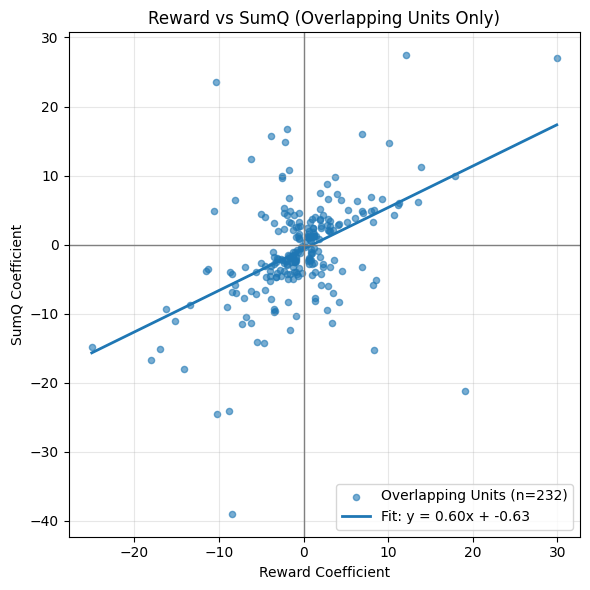

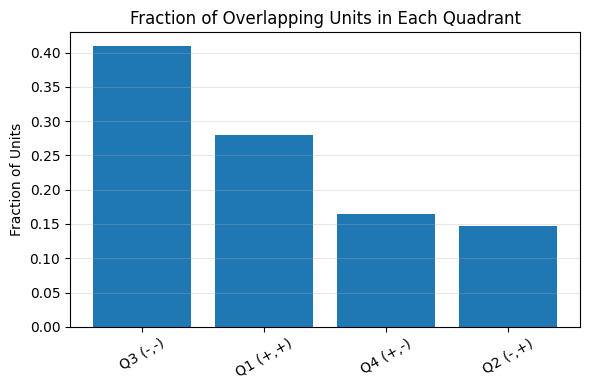

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0) Convert dict lists and compute overlaps
# =========================================================

df_reward = pd.DataFrame(output_dicts_based_on_reward)
df_sumQ   = pd.DataFrame(output_dicts_based_on_sumQ)

# Key for merging
key_cols = ["session_id", "unit_index"]

# Intersection of units
merged = df_reward.merge(df_sumQ, on=key_cols, suffixes=("_reward", "_sumQ"))

print("Number of overlapping units:", len(merged))

# =========================================================
# 1) Extract coefficients only from overlapping units
# =========================================================

reward_col = "simple_LR-QLearning_L2F1_softmax-reward-g1-s0-d0-coef_reward"
sumQ_col   = "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef_sumQ"

reward_coefs = merged[reward_col]
sumQ_coefs   = merged[sumQ_col]

df_plot = pd.DataFrame({
    "reward": reward_coefs,
    "sumQ": sumQ_coefs,
})

# =========================================================
# 2) Compute quadrants for each point
# =========================================================

def get_quadrant(row):
    if row["reward"] > 0 and row["sumQ"] > 0:
        return "Q1 (+,+)"
    elif row["reward"] < 0 and row["sumQ"] > 0:
        return "Q2 (-,+)"
    elif row["reward"] < 0 and row["sumQ"] < 0:
        return "Q3 (-,-)"
    elif row["reward"] > 0 and row["sumQ"] < 0:
        return "Q4 (+,-)"
    else:
        return "On Axis"

df_plot["quadrant"] = df_plot.apply(get_quadrant, axis=1)

# =========================================================
# 3) Compute counts and fractions per quadrant
# =========================================================

counts = df_plot["quadrant"].value_counts()
fractions = counts / len(df_plot)

summary_table = pd.DataFrame({
    "count": counts,
    "fraction": fractions.round(3),
})

print("Quadrant Summary:")
print(summary_table)

# =========================================================
# 4) Scatter plot with fitted line (overlap only)
# =========================================================

x = df_plot["reward"].values
y = df_plot["sumQ"].values

# Fit line y = a*x + b
a, b = np.polyfit(x, y, 1)
print("\nFit:")
print(f"Slope (a): {a}")
print(f"Intercept (b): {b}")

# Line for plotting
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b

plt.figure(figsize=(6, 6))

# Scatter of overlapping units
plt.scatter(x, y, alpha=0.6, s=20, label=f"Overlapping Units (n={len(df_plot)})")

# Fitted line
plt.plot(x_line, y_line, linewidth=2, label=f"Fit: y = {a:.2f}x + {b:.2f}")

# Axes lines
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.xlabel("Reward Coefficient")
plt.ylabel("SumQ Coefficient")
plt.title("Reward vs SumQ (Overlapping Units Only)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 5) Bar plot of quadrant fractions
# =========================================================

plt.figure(figsize=(6, 4))
plt.bar(summary_table.index, summary_table["fraction"])

plt.ylabel("Fraction of Units")
plt.title("Fraction of Overlapping Units in Each Quadrant")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
